# Baselines

In [31]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

from funciones_modelado import metricas, obtener_fold

Los baselines se evalúan en validación y en test, igual que los modelos, para poder compararse con ellos.
B0 no necesita calcular nada: siempre predice 1. B1 y B2 sí calculan un valor (una mediana, una media o una tabla por grupo). Ese valor se obtiene solo con el train de cada fold, para evitar leakage.

Para cada periodo (3 folds + test) se calcula la mediana y la media con los datos anteriores, se usan como predicción en ese periodo, se mide MAE (mediana) y RMSE (media), y se compara con el error de los modelos en ese mismo periodo."

# B0
El B0 supone que el ratio = 1. ERP acierta.    

Este no se entrena, predice 1 para todas las fases. Lo que hay que hacer es medir su error en los mismos datos donde mediremos los modelos.   
Trabajaremos con las dos metricas de error, MAE y RMSE para evaluar la diferencia. 

> Interesa medir cuánto se equivoca esa regla en validación. 

> No es necesario calcular nada, siempre predice 1. 

In [32]:
df_B0 = pd.read_parquet("datos/df_split.parquet")   

In [33]:
# Predicción de B0: ratio = 1 para todas las fases (el tiempo real = el teórico)
df_B0["pred_B0"] = 1.0

# Meses de validación, leídos del archivo común
folds = pd.read_csv("datos/folds.csv", dtype=str)
MESES_VALIDACION = folds["mes_validacion"].tolist()      # ['2026-02', '2026-03', '2026-04']

# Error de B0 en cada mes de validación
filas = []
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df_B0, mes)              # B0 no entrena: solo usamos valid
    filas.append({"bloque": f"k {mes}", **metricas(valid["ratio"], valid["pred_B0"])})

# Error de B0 en test   
t = df_B0[df_B0["split"] == "test"]
filas.append({"bloque": "test", **metricas(t["ratio"], t["pred_B0"])})

# Tabla de resultados
resultados_B0 = pd.DataFrame(filas).round(3)
print(resultados_B0)

      bloque    MAE   RMSE     n
0  k 2026-02  1.144  1.794   919
1  k 2026-03  1.083  1.669   997
2  k 2026-04  1.099  1.696   971
3       test  1.020  1.590  2396


Los resultados son estables entre meses, además los valores de MAE y RMSE son notablemente altos.

- MAE     
Se mantiene en torno al 1,1. Esto supone que de media el tiempo real se aleja del teórico en un 110% del tiempo teórico (en una fase de 60 min, unos ±66 min). El MAE no tiene signo, así que no indica si el ERP se queda corto o se pasa. Conectando con la revisión del ratio donde se vieron ratios de hasta 8 unidades, podria ser que ERP se este quedando corto en sus tiempos teoricos, pero no se puede confirmar todavia.

- RMSE     
Se mantiene en torno al 1,6. Su valor es mayor que el de MAE, RMSE es sensible a fallos grandes, esto indica que los tiempos teóricos contienen errores grandes. El RMSE no se lee como una desviación media, lo útil es compararlo con el MAE.

La separación entre MAE y RMSE remarca el hecho de que hay errores grandes en la planificación, podemos entender esto como que el error no es homogéneo: hay fases que se equivocan poco y algunas que se equivocan mucho. Esto encaja con el estudio de las colas del ratio, donde un grupo de fases mantenía valores muy altos sin ser outliers.

Estos resultados hay que mirarlos con profundidad. Un MAE alto puede deberse a dos cosas: sesgo o dispersión en la planificación.

> ¿El error de B0 es sesgo o dispersión?

In [34]:
filas = []
bloques = [(f"k {mes}", obtener_fold(df_B0, mes)[1]) for mes in MESES_VALIDACION]
bloques.append(("test", df_B0[df_B0["split"] == "test"]))

for nombre, d in bloques:
    filas.append({
        "bloque":               nombre,
        "error_medio":          (d["pred_B0"] - d["ratio"]).mean(), 
        "mediana_ratio":        d["ratio"].median(),
        "%_ratio>1":            (d["ratio"] > 1).mean() * 100,
        "media_ratio":          (d["ratio"].mean()),
        "diferencia":           (d["ratio"].mean()-d["ratio"].median())
    })

sesgo_B0 = pd.DataFrame(filas).round(3)
display(sesgo_B0)

,bloque,error_medio,mediana_ratio,%_ratio>1,media_ratio,diferencia
0,k 2026-02,-1.012,1.535,74.973,2.012,0.477
1,k 2026-03,-0.957,1.579,78.937,1.957,0.378
2,k 2026-04,-0.948,1.537,74.768,1.948,0.411
3,test,-0.885,1.489,75.250,1.885,0.396


Estos resultados apunta a un sesgo, ERP se queda corto en sus estimaciones de tiempo. Aproximadamente el 75% de las fases tienen un ratio superior a 1,  3 de cada 4 fases tardan más de lo planificado. La mediana con un ratio de 1,5 indica que el tiempo práctico de una fase tipica supera un 50% al teorico. El error medio se ha calculando como ratio_ERP - ratio_Real, qye este se mantenga en torno al -0,9 refuerza que haya un sesgo hacia un tiempo teorico menor al práctico. Estos resultados son estables en el tiempo. 

Analizando la relación entre la media y la mediana del ratio se aprecia que la media queda claramente por encima de la mediana en todos los bloques, unos 0,4 puntos sobre el ratio. Comom ya se detecto al estudiar el ratio, la distribución del ratio es asimétrica, con cola a la derecha. Hay un grupo de fases con ratios muy altos que tira de la media hacia arriba. La asimetria es estable en todos los bloques. 

El hecho que la diferencia sea positiva puede ser un indicio de tener una cola hacia la derecha. Encaja con lo que se vio al analizar el ratio en `8.Variable_Objetivo`. 

Dado la naturaleza multiplicativa del ratio, voy a proceder a explorar los mismos resultados pero con el **log(ratio)**

In [35]:
filas = []
bloques = [(f"k {mes}", obtener_fold(df_B0, mes)[1]) for mes in MESES_VALIDACION]
bloques.append(("test", df_B0[df_B0["split"] == "test"]))

for nombre, d in bloques:
    log_ratio = np.log(d["ratio"])
    filas.append({
        "bloque":              nombre,
        "error_medio_log":     (0 - log_ratio).mean(),
        "mediana_log":         log_ratio.median(),
        "%_log>0":             (log_ratio > 0).mean() * 100,
        "media_log":           log_ratio.mean(),
        "diferencia_log":      log_ratio.mean() - log_ratio.median(),
    })

sesgo_B0_log = pd.DataFrame(filas).round(3)
display(sesgo_B0_log)

,bloque,error_medio_log,mediana_log,%_log>0,media_log,diferencia_log
0,k 2026-02,-0.470,0.429,74.973,0.470,0.042
1,k 2026-03,-0.467,0.457,78.937,0.467,0.010
2,k 2026-04,-0.443,0.430,74.768,0.443,0.013
3,test,-0.430,0.398,75.250,0.430,0.032


Revisando las mismas métricas el comportamiento es estable entre bloques, igual que en escala ratio, aún así con el logaritmo del ratio se aprecian cambios. Concretamente la media y la mediana convergen. Su diferencia es mínima en comparación con los resultados del ratio sin logaritmo. Esto apunta a que el log(ratio) es mucho más simétrico que el ratio, algo que ya se vio en el notebook `8.Variable_Objetivo`.

Estos datos apoyan incluirlo en los experimentos, aunque la cercanía entre media y mediana es un indicio de simetría, no una prueba completa.

Cabe destacar que esta notable simetría en la escala del logaritmo hace pensar que las desviaciones son de tipo multiplicativo. Entendiendo como desviación la diferencia entre real y teórico.

Entonces aquí lo que vemos es que el log altera la escala en la que se miden las desviaciones, y en esta escala se comportan de una forma más simétrica. Aun así, el sesgo sigue presente: el 75% de las fases mantiene log(ratio) > 0. El log cambia la forma de la distribución, pero no elimina el sesgo.

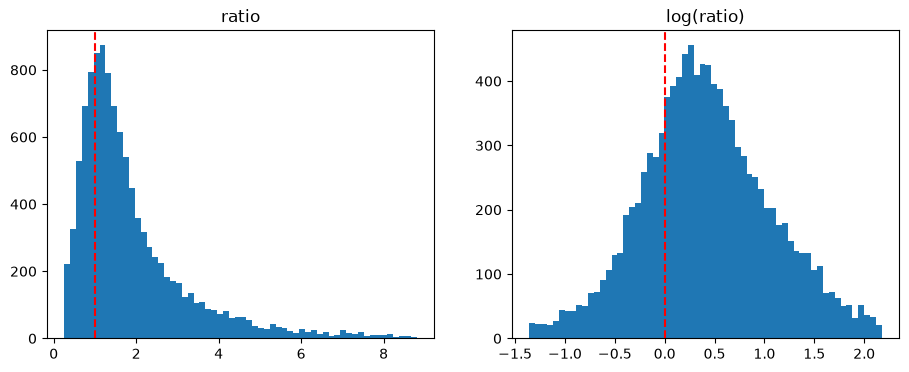

Asimetría ratio:      1.94
Asimetría log(ratio): 0.13


In [59]:
train_k3, _ = obtener_fold(df_B0, MESES_VALIDACION[2])     # train del fold 1 (jun 2025 – ene 2026)

ratio = train_k3["ratio"]
log_ratio = np.log(ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(ratio, bins=60)
ax1.set_title("ratio")
ax1.axvline(1, color="red", ls="--")

ax2.hist(log_ratio, bins=60)
ax2.set_title("log(ratio)")
ax2.axvline(0, color="red", ls="--")
plt.show()

print("Asimetría ratio:     ", round(ratio.skew(), 2))
print("Asimetría log(ratio):", round(log_ratio.skew(), 2))

Los gráficos muestran la distribución del ratio y del log(ratio) en los datos de entrenamiento del primer fold (junio 2025 – enero 2026).

En ambas escalas se aprecia un desplazamiento hacia la derecha: la mayor parte de las fases queda por encima de ratio = 1 (log = 0). Esto refuerza el sesgo ya observado en la estimación de tiempos.

La asimetría del ratio es de 1,97, fuertemente alta. Supera el valor de 1, a partir del cual se considera una asimetría fuerte, y denota una cola larga a la derecha.

El log reduce esta asimetría a 0,14, dando una distribución mucho más simétrica.

Ambas distribuciones tienen las dos colas cortadas. Esto se debe a la limpieza de outliers realizada con el corte IQR sobre el log(ratio) (intervalo admisible 0,257 – 8,814).

Aunque el log(ratio) presente una distribución más simétrica, eso no implica que el modelo vaya a predecir mejor con esa variable. La elección entre ratio y log(ratio) se hará comparando los modelos fuera de muestra.

> se usa .skew de pandas para calcular la asimetria. 

En `8.Variable_Objetivo` inspeccioné la cola del ratio y se detecto que son las fases con tiempos más bajos las que acumulan tiempo más altos.     

In [37]:
# guardar las predicciones B0
df_B0[["IDMOTask", "split", "mes_orden", "ratio", "pred_B0"]].to_parquet(
    "predicciones/b0.parquet", index=False)

# B1
El análisis de B0 mostró un sesgo claro: en torno al 75 % de las fases tienen un ratio superior a 1, y el comportamiento es estable en todos los bloques. El ERP no se equivoca por igual hacia los dos lados: en su previsión de tiempos se queda corto de forma sistemática.

De este allazgo surge B1, incorporando este sesgo. En lugar de predecir ratio = 1, predice para todas las fases el ratio típico observado en entrenamiento. Se calculan dos versiones: 
- la mediana, asociada al MAE
- la media, asociada al RMSE. 

> La constante se calcula solo con el train de cada fold, igual que los modelos.

Si lo modelos superar a B0 puede deberse únicamente a corregir el sesgo. Superar a B1, en cambio, indica que las variables aportan información adicional sobre la desviación de cada fase.

In [38]:
display(df_B0.sample(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio,inicio_orden,mes_orden,split,maquina_no_vista,pred_B0
11483,2026-05-20 20:14:52.687,ebf6b390-6f92-456f-b56a-c5b4df8fabe6,OF2603741,CHO-CNYPUN,CM05,CH,B,BR,1.0,143.0,0.73345,2026-04-29 16:42:50.540,2026-04,desarrollo,False,1.0


In [39]:
df_B1 = df_B0[["IDMOTask", "split", "mes_orden", "ratio"]].copy()
df_B1["pred_B1_mediana"] = np.nan
df_B1["pred_B1_media"]   = np.nan

# Validación: la constante se aprende en el train de cada fold
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df_B1, mes)
    df_B1.loc[valid.index, "pred_B1_mediana"] = train["ratio"].median()
    df_B1.loc[valid.index, "pred_B1_media"]   = train["ratio"].mean()

# Test: la constante se aprende con todo el desarrollo
B1_desarrollo = df_B1[df_B1["split"] == "desarrollo"] # split: desarrollo o test
B1_test = df_B1["split"] == "test"
df_B1.loc[B1_test, "pred_B1_mediana"] = B1_desarrollo["ratio"].median()
df_B1.loc[B1_test, "pred_B1_media"]   = B1_desarrollo["ratio"].mean()

# Métricas por bloque (mismo formato que B0)
filas = []
bloques = [(f"k {mes}", obtener_fold(df_B1, mes)[1]) for mes in MESES_VALIDACION]
bloques.append(("test", df_B1[B1_test]))

for nombre, d in bloques:
    m_med  = metricas(d["ratio"], d["pred_B1_mediana"])
    m_mean = metricas(d["ratio"], d["pred_B1_media"])
    filas.append({"bloque": nombre,
                  "constante_mediana": d["pred_B1_mediana"].iloc[0],
                  "MAE_B1_mediana":    m_med["MAE"],
                  "constante_media":   d["pred_B1_media"].iloc[0],
                  "RMSE_B1_media":     m_mean["RMSE"],
                  "n":                 m_med["n"]})

resultados_B1 = pd.DataFrame(filas).round(3)
display(resultados_B1)

,bloque,constante_mediana,MAE_B1_mediana,constante_media,RMSE_B1_media,n
0,k 2026-02,1.448,1.026,1.859,1.489,919
1,k 2026-03,1.453,0.926,1.873,1.371,997
2,k 2026-04,1.466,0.971,1.881,1.408,971
3,test,1.471,0.905,1.887,1.321,2396


- `constante_mediana`: El valor que predice B1-mediana para el ratio en todas las fases de ese bloque.     
- `MAE_B1_mediana`: El MAE que se obtiene al predecir esa constante en todas las fases del bloque.
- `constante_media`: la media del ratio en el train de ese fold.
- `RMSE_B1_media`: El RMSE que se obtiene al predecir esa constante.

B1-mediana:  constante_mediana  →  MAE_B1_mediana (cuánto falla tomando la mediana)        
B1-media:    constante_media    →  RMSE_B1_media  (cuánto falla tomando la media)

La constante se toma para el conjunto completo.

In [40]:
# guardar las predicciones B1
df_B1[["IDMOTask", "split", "mes_orden", "ratio", "pred_B1_mediana", "pred_B1_media"]].to_parquet(
    "predicciones/b1.parquet", index=False)

# Las fases de training no tiene información en las columnas "pred_B1_mediana" y "pred_B1_media" (NaN)
    # No interesa que la tengan, ya que evaluaré la validación y el test
        # Si se han tomado los datos de train para calcular las variables 

## B2
B1 compara los modelos con una única constante para todas las fases. B2 da un paso más: calcula una constante para cada grupo de fases ([agrupación]). Cada fase recibe la mediana (o la media) del ratio de su grupo en entrenamiento.

B2 no es un modelo, sino una tabla de consulta sencilla, como la que podría construir un planificador en una hoja de cálculo. Ya utiliza información de las variables, pero de la forma más simple posible.

Su objetivo es comprobar si los modelos aportan algo más que esa tabla. Si un modelo supera a B2, capta información que la tabla no recoge. Si no lo supera, una tabla por grupos sería suficiente.

Las constantes de cada grupo se calculan solo con el train de cada fold. Los grupos con pocas fases en entrenamiento, o que no aparecen en él, reciben la constante global de B1 como respaldo.

> Nunca se incluye en el cálculo el mismo mes que se evalúa, ya que B2 se toma como una predicción.

Elegir la agrupación con la que formar la tabla:

In [41]:
display(df_B0.sample(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio,inicio_orden,mes_orden,split,maquina_no_vista,pred_B0
7796,2025-09-24 11:19:41.883,75e425f6-f59e-47bd-8892-1a8f3d819240,OF2509040,TCN,TN05,TCN,E,ELR,30.0,120.0,1.3325,2025-09-24 11:19:41.883,2025-09,desarrollo,False,1.0


In [42]:
# tomo el periodo de validación con menos datos para investigar las agrupaciones

train_f1, _ = obtener_fold(df_B0, MESES_VALIDACION[0])     # train del fold 1 (jun–ene)

opciones = {
    "Máquina":                   ["CodigoMaquina"],
    "Familia de máquinas":       ["Familia Maquinas"],
    "Tipo de fase":              ["TipoFase"],
    "Familia × tipo de fase":    ["Familia Maquinas", "TipoFase"],
}

filas = []
for nombre, cols in opciones.items():
    tamaños = train_f1.groupby(cols).size()
    filas.append({"agrupación": nombre,
                  "n_grupos": len(tamaños),
                  "grupos_<30_fases": (tamaños < 30).sum(),
                  "%_fases_en_grupos_<30": round(tamaños[tamaños < 30].sum() / len(train_f1) * 100, 1)})

display(pd.DataFrame(filas))

,agrupación,n_grupos,grupos_<30_fases,%_fases_en_grupos_<30
0,Máquina,24,3,0.4
1,Familia de máquinas,9,0,0.0
2,Tipo de fase,38,17,1.8
3,Familia × tipo de fase,94,69,4.1


La maquina es más interesante para estudiar la desviación de tiempos.  

- **Máquina concreta**: más detalle. Si dos tornos de la misma familia se comportan distinto, B2 lo recoge.    
- **Familia**: más estable (ningún grupo pequeño), pero trata igual a todas las máquinas de una misma familia.


#### Fallback para grupos pequeños o no vistos

B2 predice para cada fase la mediana del ratio de su grupo (familia o máquina), calculada solo con el train del fold. Esto plantea dos problemas:

- **Grupo pequeño**: si un grupo tiene pocas fases en train, su mediana es poco fiable (ruido).
- **Grupo no visto**: si un grupo no aparece en train, no hay mediana que asignarle y el `.map()` que se utilizará devuelve NaN.

Para cubrir ambos casos se aplica un **fallback**. Todas las fases reciben una predicción y se evalúan; lo que cambia es qué mediana se les asigna:

- Si su grupo tiene **≥ 30** fases en train reciben la **mediana de su grupo**.
- Si su grupo tiene **< 30** fases en train o **no aparece** entonces no se usa la mediana del grupo (poco fiable o inexistente) y reciben la **mediana global del train**, que es la misma constante que predice B1 en ese bloque.

La idea es que B2 recurra a B1 cuando no tiene información suficiente sobre el grupo. La mediana global se calcula con todas las fases del train, incluidas las de grupos pequeños.

Lo mismo se aplica a la versión con media: los mismos grupos caen en el fallback y reciben la media global del train (constante de B1-media).

#### Métricas B2-grupo_maquinas

In [43]:
MIN_FASES = 30

df_B2 = df_B0[["IDMOTask", "split", "mes_orden", "ratio"]].copy()
df_B2["pred_B2_familia_mediana"] = np.nan
df_B2["pred_B2_familia_media"] = np.nan 

tablas_familia = {}
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df_B0, mes)
# train
    mediana_global = train["ratio"].median() # Mediana global del train (para fallback)
    media_global   = train["ratio"].mean() 
    resumen = train.groupby("Familia Maquinas")["ratio"].agg(["median", "mean", "size"]) # Tabla consulta (solo train)
    tablas_familia[mes] = resumen # guardar tabla resumen (diccionario de tablas)
    grupos_ok = resumen["size"] >= MIN_FASES # Tabla consulta aplicando el fallback
    mediana_familias = resumen.loc[grupos_ok, "median"]
    media_familias   = resumen.loc[grupos_ok, "mean"]                       
# validación
    pred_mediana = valid["Familia Maquinas"].map(mediana_familias) # 
    n_fallback = pred_mediana.isna().sum()
    df_B2.loc[valid.index, "pred_B2_familia_mediana"] = pred_mediana.fillna(mediana_global)
    
    pred_media = valid["Familia Maquinas"].map(media_familias)              
    df_B2.loc[valid.index, "pred_B2_familia_media"] = pred_media.fillna(media_global)  
    
    print(f"{mes}: {len(valid)} fases valid | {n_fallback} con fallback")

# Calcular test
desarrollo = df_B0[df_B0["split"] == "desarrollo"]
test       = df_B0[df_B0["split"] == "test"]

mediana_global_dev = desarrollo["ratio"].median() # mediana desarroyo (fallbacks)
media_global_dev   = desarrollo["ratio"].mean() # media
resumen_dev = desarrollo.groupby("Familia Maquinas")["ratio"].agg(["median", "mean","size"])
tablas_familia["test"] = resumen_dev

grupos_ok_dev = resumen_dev["size"] >= MIN_FASES                            
mediana_familias_dev = resumen_dev.loc[grupos_ok_dev, "median"]
media_familias_dev   = resumen_dev.loc[grupos_ok_dev, "mean"]               

pred_test_mediana = test["Familia Maquinas"].map(mediana_familias_dev)
print(f"test: {len(test)} fases | {pred_test_mediana.isna().sum()} con fallback")
df_B2.loc[test.index, "pred_B2_familia_mediana"] = pred_test_mediana.fillna(mediana_global_dev)

pred_test_media = test["Familia Maquinas"].map(media_familias_dev)          
df_B2.loc[test.index, "pred_B2_familia_media"] = pred_test_media.fillna(media_global_dev)  

2026-02: 919 fases valid | 0 con fallback
2026-03: 997 fases valid | 0 con fallback
2026-04: 971 fases valid | 0 con fallback
test: 2396 fases | 0 con fallback


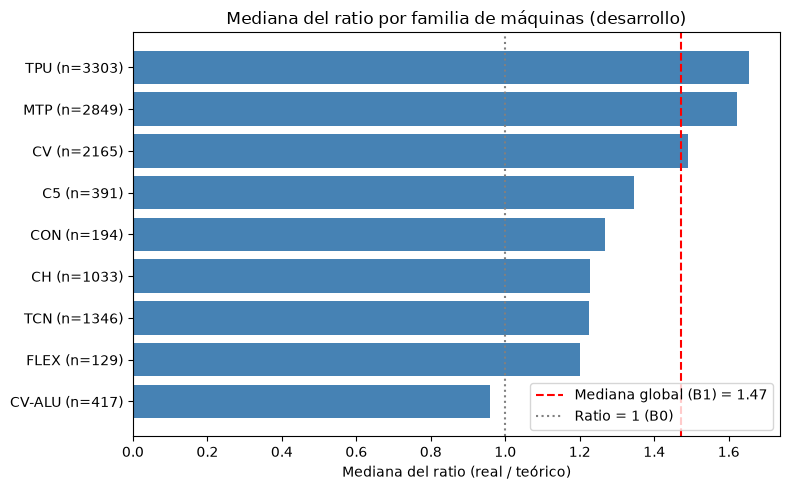

In [44]:
resumen = tablas_familia["test"].sort_values("median")
etiquetas = [f"{fam} (n={n})" for fam, n in zip(resumen.index, resumen["size"])]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(etiquetas, resumen["median"], color="steelblue")
ax.axvline(mediana_global_dev, color="red", linestyle="--",
           label=f"Mediana global (B1) = {mediana_global_dev:.2f}")
ax.axvline(1, color="grey", linestyle=":", label="Ratio = 1 (B0)")

ax.set_xlabel("Mediana del ratio (real / teórico)")
ax.set_title("Mediana del ratio por familia de máquinas (desarrollo)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [45]:
pd.concat({k: v["median"] for k, v in tablas_familia.items()}, axis=1).round(2)

,2026-02,2026-03,2026-04,test
Familia Maquinas,,,,
C5,1.31,1.31,1.32,1.35
CH,1.24,1.22,1.22,1.23
CON,1.31,1.29,1.27,1.27
CV,1.48,1.48,1.49,1.49
CV-ALU,0.95,0.96,0.96,0.96
FLEX,1.14,1.17,1.20,1.20
MTP,1.61,1.62,1.61,1.62
TCN,1.27,1.25,1.24,1.22
TPU,1.56,1.61,1.63,1.66


#### Métricas B2-máquina

Ahora lo mismo per para la maquina no para el grupo:

In [46]:
df_B2["pred_B2_maquina_mediana"] = np.nan
df_B2["pred_B2_maquina_media"] = np.nan

tablas_maquina = {}
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df_B0, mes)
# train
    mediana_global = train["ratio"].median() # Mediana global del train (para fallback)
    media_global   = train["ratio"].mean() # Media global del train (para fallback)
    resumen = train.groupby("CodigoMaquina")["ratio"].agg(["median", "mean", "size"]) # Tabla consulta (solo train)
    tablas_maquina[mes] = resumen # guardar tabla resumen (diccionario de tablas)
    grupos_ok = resumen["size"] >= MIN_FASES # máquinas con suficientes fases
    mediana_maquinas = resumen.loc[grupos_ok, "median"] # Tabla consulta aplicando el fallback (mediana)
    media_maquinas   = resumen.loc[grupos_ok, "mean"] # Tabla consulta aplicando el fallback (media)
# validación
    pred = valid["CodigoMaquina"].map(mediana_maquinas) # predicción con mediana
    print(f"k {mes}: {len(valid)} fases valid | {pred.isna().sum()} con fallback") # mismo nº para media (mismo filtro)
    df_B2.loc[valid.index, "pred_B2_maquina_mediana"] = pred.fillna(mediana_global)

    pred_media = valid["CodigoMaquina"].map(media_maquinas) # predicción con media
    df_B2.loc[valid.index, "pred_B2_maquina_media"] = pred_media.fillna(media_global)

# Calcular test (desarrollo, test, mediana_global_dev y media_global_dev vienen de la celda de familia)
resumen_dev = desarrollo.groupby("CodigoMaquina")["ratio"].agg(["median", "mean", "size"]) # Tabla consulta (todo desarrollo)
tablas_maquina["test"] = resumen_dev
grupos_ok_dev = resumen_dev["size"] >= MIN_FASES # máquinas con suficientes fases
mediana_maquinas_dev = resumen_dev.loc[grupos_ok_dev, "median"] # Tabla consulta aplicando el fallback (mediana)
media_maquinas_dev   = resumen_dev.loc[grupos_ok_dev, "mean"] # Tabla consulta aplicando el fallback (media)

pred_test = test["CodigoMaquina"].map(mediana_maquinas_dev) # predicción test con mediana
print(f"test: {len(test)} fases | {pred_test.isna().sum()} con fallback")
df_B2.loc[test.index, "pred_B2_maquina_mediana"] = pred_test.fillna(mediana_global_dev)

pred_test_media = test["CodigoMaquina"].map(media_maquinas_dev) # predicción test con media
df_B2.loc[test.index, "pred_B2_maquina_media"] = pred_test_media.fillna(media_global_dev)

k 2026-02: 919 fases valid | 0 con fallback
k 2026-03: 997 fases valid | 0 con fallback
k 2026-04: 971 fases valid | 0 con fallback
test: 2396 fases | 37 con fallback


In [47]:
test.loc[pred_test.isna(), "CodigoMaquina"].value_counts()

CodigoMaquina
CM19        36
Otras_C5     1
Name: count, dtype: int64

#### Métricas B2 (familia y máquina)

In [48]:
filas = []
for bloque in MESES_VALIDACION + ["test"]:
    if bloque == "test":
        datos = df_B2[df_B2["split"] == "test"]
    else:
        datos = df_B2[(df_B2["split"] == "desarrollo") & (df_B2["mes_orden"] == bloque)]

    m_fam       = metricas(datos["ratio"], datos["pred_B2_familia_mediana"]) # familia con mediana (para MAE)
    m_fam_media = metricas(datos["ratio"], datos["pred_B2_familia_media"]) # familia con media (para RMSE)
    m_maq       = metricas(datos["ratio"], datos["pred_B2_maquina_mediana"]) # máquina con mediana (para MAE)
    m_maq_media = metricas(datos["ratio"], datos["pred_B2_maquina_media"]) # máquina con media (para RMSE)
    filas.append({"bloque": bloque if bloque == "test" else f"k {bloque}",
                  "MAE_B2_familia_mediana": m_fam["MAE"],
                  "MAE_B2_maquina_mediana": m_maq["MAE"],
                  "RMSE_B2_familia_media": m_fam_media["RMSE"],
                  "RMSE_B2_maquina_media": m_maq_media["RMSE"],
                  "n": m_fam["n"]})

tabla_B2 = pd.DataFrame(filas)
tabla_B2

,bloque,MAE_B2_familia_mediana,MAE_B2_maquina_mediana,RMSE_B2_familia_media,RMSE_B2_maquina_media,n
0,k 2026-02,0.992749,0.983415,1.450262,1.424921,919
1,k 2026-03,0.897456,0.887696,1.332126,1.315358,997
2,k 2026-04,0.942689,0.927921,1.364735,1.341708,971
3,test,0.882588,0.863235,1.290086,1.267190,2396


MAE se evalúa con las predicciones de mediana y el RMSE con las de media, ya que cada una es la constante que minimiza su métrica. Los valores de MAE y RMSE no se comparan entre sí, sino cada uno con el mismo indicador de otros baselines y modelos.

- **B2-familia**: el fallback no se activa en ningún bloque (0 fases en validación y en test). Todas las familias tienen ≥ 30 fases en el train de cada fold.
- **B2-máquina**: no se activa en validación; en test se activa en 37 fases, 36 de ellas de **CM19**, máquina que no aparece en desarrollo.

B2 reduce el error de B1 en todos los bloques, tanto en MAE (de 0,905 a 0,883 con familia y a 0,863 con máquina, en test) como en RMSE (de 1,321 a 1,290 y a 1,267, en test). Asignar un sesgo distinto a cada grupo mejora la corrección de un sesgo común para todas las fases.

B2-máquina obtiene menor error que B2-familia en todos los bloques, aunque la diferencia es pequeña (en test, 0,863 frente a 0,883 en MAE). B2-máquina se toma como el baseline más exigente con el que comparar los modelos.

In [49]:
display(df_B2)

,IDMOTask,split,mes_orden,ratio,pred_B2_familia_mediana,pred_B2_familia_media,pred_B2_maquina_mediana,pred_B2_maquina_media
0,ee76d685-a4cc-47d4-b418-6e33d2ae2921,desarrollo,2025-09,1.988889,NaN,NaN,NaN,NaN
1,3c6cccb8-2326-4d66-9714-b09ac436be82,desarrollo,2025-10,0.826333,NaN,NaN,NaN,NaN
2,503758e9-3758-40dc-8b3f-fca57d71de65,desarrollo,2026-02,0.577435,1.477720,1.832470,1.502381,1.911885
3,ca179af3-8048-4037-a74a-57abd7285c4b,desarrollo,2025-12,3.047619,NaN,NaN,NaN,NaN
4,89527791-13b3-45d8-826a-dd93ee1b37e8,desarrollo,2026-02,0.877084,1.608009,2.174039,1.631850,2.193287
...,...,...,...,...,...,...,...,...
14218,d569f984-cdaf-4bc4-b68b-74e48a8e1151,desarrollo,2025-07,4.881818,NaN,NaN,NaN,NaN
14219,f49f0db4-f64f-4bc7-881e-ab474c553482,desarrollo,2026-02,6.940909,1.560476,1.990526,1.721680,2.164883
14220,9a4f079f-f5c3-4605-b5ad-576613629ee4,test,2026-05,1.304167,1.655000,2.119049,1.820264,2.305343
14221,d3bea639-6fe6-46cc-b129-4bcf02554313,desarrollo,2025-06,1.165990,NaN,NaN,NaN,NaN


In [50]:
df_B2.to_parquet("predicciones/b2.parquet", index=False)

Unirlo todo en una tabla:

In [51]:
print(resultados_B0["bloque"].tolist())
print(resultados_B1["bloque"].tolist())
print(tabla_B2["bloque"].tolist())

['k 2026-02', 'k 2026-03', 'k 2026-04', 'test']
['k 2026-02', 'k 2026-03', 'k 2026-04', 'test']
['k 2026-02', 'k 2026-03', 'k 2026-04', 'test']


In [52]:
escalera = (
    resultados_B0[["bloque", "MAE", "RMSE"]].rename(columns={"MAE": "MAE_B0", "RMSE": "RMSE_B0"})
    .merge(resultados_B1[["bloque", "MAE_B1_mediana", "RMSE_B1_media"]], on="bloque")
    .merge(tabla_B2.drop(columns="n"), on="bloque")
)
escalera = escalera.round(3)

display(escalera)

,bloque,MAE_B0,RMSE_B0,MAE_B1_mediana,RMSE_B1_media,MAE_B2_familia_mediana,MAE_B2_maquina_mediana,RMSE_B2_familia_media,RMSE_B2_maquina_media
0,k 2026-02,1.144,1.794,1.026,1.489,0.993,0.983,1.450,1.425
1,k 2026-03,1.083,1.669,0.926,1.371,0.897,0.888,1.332,1.315
2,k 2026-04,1.099,1.696,0.971,1.408,0.943,0.928,1.365,1.342
3,test,1.020,1.590,0.905,1.321,0.883,0.863,1.290,1.267


In [53]:
escalera.to_csv("predicciones/escalera_baselines.csv", index=False)

### Comparar la evolución de los baselines

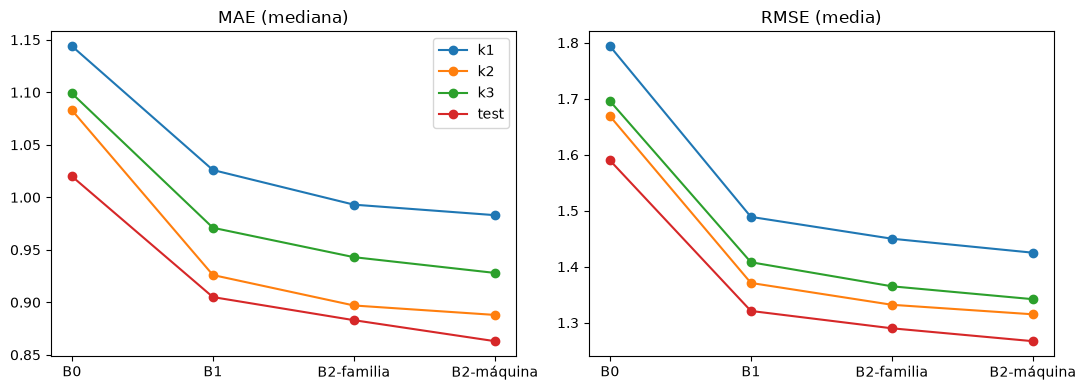

In [56]:
cols_mae  = ["MAE_B0", "MAE_B1_mediana", "MAE_B2_familia_mediana", "MAE_B2_maquina_mediana"]
cols_rmse = ["RMSE_B0", "RMSE_B1_media", "RMSE_B2_familia_media", "RMSE_B2_maquina_media"]
nombres   = ["B0", "B1", "B2-familia", "B2-máquina"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
k = 0
for _, fila in escalera.iterrows():
    if fila["bloque"] == "test":       
        etiqueta = fila["bloque"]
    else:                             
        k += 1
        etiqueta = f"k{k}"

    ax1.plot(nombres, fila[cols_mae],  marker="o", label=etiqueta)
    ax2.plot(nombres, fila[cols_rmse], marker="o", label=etiqueta)

ax1.set_title("MAE (mediana)")
ax2.set_title("RMSE (media)")
ax1.legend()
plt.tight_layout()
plt.show()

#### Escalera de baselines

En todos los bloques y en ambas métricas el error disminuye en cada escalón: B0 → B1 → B2-familia → B2-máquina. El orden entre bloques se mantiene en todos los baselines (test con el menor error, febrero con el mayor).

- **MAE (validación):** de 1.08–1.14 en B0 a 0.89–0.98 en B2-máquina.
- **RMSE (validación):** de 1.67–1.79 en B0 a 1.32–1.43 en B2-máquina.

B2-máquina es el baseline con menor error en todos los bloques y se toma como listón principal para los modelos; B1 se mantiene como referencia para separar la corrección del sesgo global del aporte de las variables.